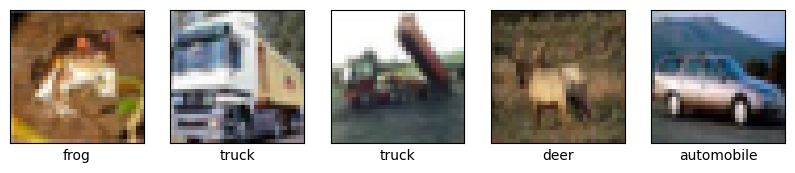

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.3901 - loss: 1.6736 - val_accuracy: 0.4432 - val_loss: 1.5685
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.4865 - loss: 1.4265 - val_accuracy: 0.5079 - val_loss: 1.3642
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.5276 - loss: 1.3237 - val_accuracy: 0.5286 - val_loss: 1.3221
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.5520 - loss: 1.2526 - val_accuracy: 0.5538 - val_loss: 1.2534
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.5758 - loss: 1.1926 - val_accuracy: 0.5641 - val_loss: 1.2298
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5641 - loss: 1.2298
Test Accuracy: 0.5641000270843506


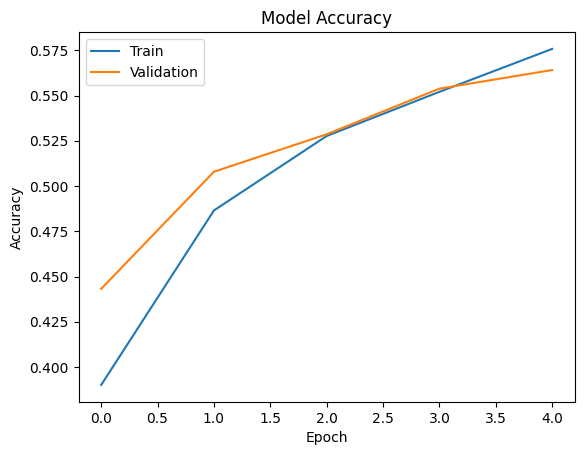

In [ ]:
# CNN Variant: LeNet Implementation on CIFAR-10
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
# x = image of cat
# y = label number for cat = 3
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# normalize pixel values (0 to 1)S
x_train = x_train / 255.0
x_test = x_test / 255.0

# ------------------------------
# Display first 5 images from training set
# ------------------------------

# CIFAR-10 class labels
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,2))  # wide figure
for i in range(5):  # first 5 images
    plt.subplot(1,5,i+1)  # 1 row, 5 columns
    plt.xticks([])  # remove x-axis ticks
    plt.yticks([])  # remove y-axis ticks
    plt.grid(False)  # remove grid
    plt.imshow(x_train[i])  # display image
    plt.xlabel(class_names[y_train[i][0]])  # show true label
plt.show()

# ------------------------------
# Build LeNet CNN model
# ------------------------------
model = models.Sequential([

    # 1st Convolution Layer
    layers.Conv2D(filters=6,
                  kernel_size=(5,5),
                  activation='relu',
                  input_shape=(32,32,3)),
    # 1st Pooling Layer
    layers.AveragePooling2D(pool_size=(2,2)),
    # 2nd Convolution Layer
    layers.Conv2D(filters=16,
                  kernel_size=(5,5),
                  activation='relu'),
    # 2nd Pooling Layer
    layers.AveragePooling2D(pool_size=(2,2)),
    layers.Flatten(),
    # Dense(120) → learns feature combinations
    layers.Dense(120, activation='relu'),
    # Dense(84) → refines features before output
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
    # 10 neurons because CIFAR-10 has 10 classes.
    # Example output:
    # cat → 0.80
    # dog → 0.10
    # car → 0.05
    # Highest probability = predicted class.
    # Converts values into probability.
])

# Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
# updates weights to reduce error.
# measures error between predicted and actual value.
# shows accuracy during training

# Train model
history = model.fit(x_train,
                    y_train,
                    epochs=5,
                    validation_data=(x_test, y_test))
# train dataset 5 times
# check performance on test data

# Evaluate model
# Checks model performance on test data.
loss, accuracy = model.evaluate(x_test, y_test)
# Returns:
# loss → error
# accuracy → correct predictions %
# Displays final accuracy.
print("Test Accuracy:", accuracy)
# Example:
# Test Accuracy: 0.65
# 65% images classified correctly.

# ------------------------------
# Plot training and validation accuracy graph
# ------------------------------
plt.plot(history.history['accuracy'])  # plot training accuracy
plt.plot(history.history['val_accuracy'])  # plot validation accuracy
plt.title('Model Accuracy')  # graph title
plt.xlabel('Epoch')  # x-axis label
plt.ylabel('Accuracy')  # y-axis label
plt.legend(['Train','Validation'])  # legend explains graph lines
plt.show()

# Overall Flow:
# Image → CNN layers → Feature extraction → Dense layers → Prediction → Accuracy graph